# Modellösszehasonlítás - Predictive Maintenance projekt

Ebben a notebookban a projekt során elkészített modellek eredményeit hasonlítjuk össze.

A cél nem az összes modellverzió részletes elemzése, hanem modellcsaládonként a legjobb eredmény kiválasztása és ezek összehasonlítása.

A vizsgált modellcsaládok:

- Logistic Regression
- SVM
- Naive Bayes
- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost

Az összehasonlítás fő metrikája az F1-score, mert az adathalmaz erősen kiegyensúlyozatlan.

## 1. Az összehasonlítás célja

A predictive maintenance feladatban a cél annak előrejelzése, hogy egy gép meghibásodik-e.

Az adathalmazban a meghibásodási esetek ritkák, ezért az accuracy önmagában félrevezető lehet. Egy olyan modell is magas accuracyt érhetne el, amely szinte mindig a többségi, hibamentes osztályt prediktálja.

Ezért az összehasonlításban az alábbi metrikákat vizsgáljuk:

- accuracy,
- precision,
- recall,
- F1-score,
- ROC-AUC,
- average precision, ahol rendelkezésre áll.

A modellcsaládonkénti legjobb változatot elsődlegesen F1-score alapján választjuk ki. Másodlagos szempontként a recallt és a precisiont is figyelembe vesszük.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 2. Eredményfájlok kezelése

A csapat tagjai külön notebookokban dolgoztak, ezért az eredmény CSV-k nem teljesen egységes formátumban készültek.

Ebben a notebookban először beolvassuk ezeket a fájlokat, majd egységes szerkezetre alakítjuk őket.

Az egységesített eredménytábla minden modellnél az alábbi információkat fogja tartalmazni:

- modellcsalád,
- modellnév,
- verzió,
- accuracy,
- precision,
- recall,
- F1-score,
- ROC-AUC,
- average precision,
- threshold, ha van,
- forrásfájl.

In [2]:
def find_file(filename, search_root=None):
    """
    Megkeres egy fájlt a projektmappában.
    
    Ha a fájl nincs közvetlenül az aktuális mappában,
    akkor rekurzívan keresünk a projekt gyökere felől.
    """
    if search_root is None:
        search_root = Path.cwd()
        
        # Ha a notebook például Codes/ModelComparison mappában van,
        # akkor két szinttel feljebb valószínűleg a projekt gyökere található.
        for _ in range(3):
            if (search_root / filename).exists():
                return search_root / filename
            if search_root.parent != search_root:
                search_root = search_root.parent
    
    search_root = Path(search_root)
    
    matches = list(search_root.rglob(filename))
    
    if len(matches) == 0:
        print(f"Nem található fájl: {filename}")
        return None
    
    if len(matches) > 1:
        print(f"Több találat a fájlra: {filename}")
        for match in matches:
            print(" -", match)
        print("Az első találatot használjuk.")
    
    return matches[0]

In [3]:
expected_files = {
    "boosting": "boosting_results_tuned.csv",
    "naive_bayes_tuned": "naive_bayes_results_tuned.csv",
    "naive_bayes_baseline": "naive_bayes_results.csv",
    
    "decision_tree_final": "decision_tree_final_results.csv",
    "decision_tree_threshold": "decision_tree_threshold_comparison.csv",
    
    "random_forest_final": "random_forest_final_results.csv",
    "random_forest_threshold": "random_forest_threshold_comparison.csv",
    
    "logreg_threshold": "logreg_threshold_comparison.csv",
    "svm_threshold": "svm_threshold_comparison.csv"
}

In [4]:
file_paths = {}

for key, filename in expected_files.items():
    path = find_file(filename)
    file_paths[key] = path

file_paths

{'boosting': WindowsPath('c:/Users/aszen/Desktop/ÓBUDAI MSC/02_2025-2026-2/05_Gépi tanulás/MLBeadando/Codes/Models/Boosting/boosting_results_tuned.csv'),
 'naive_bayes_tuned': WindowsPath('c:/Users/aszen/Desktop/ÓBUDAI MSC/02_2025-2026-2/05_Gépi tanulás/MLBeadando/Codes/Models/Naive/naive_bayes_results_tuned.csv'),
 'naive_bayes_baseline': WindowsPath('c:/Users/aszen/Desktop/ÓBUDAI MSC/02_2025-2026-2/05_Gépi tanulás/MLBeadando/Codes/Models/Naive/naive_bayes_results.csv'),
 'decision_tree_final': WindowsPath('c:/Users/aszen/Desktop/ÓBUDAI MSC/02_2025-2026-2/05_Gépi tanulás/MLBeadando/Codes/Models/DecisionTree/decision_tree_final_results.csv'),
 'decision_tree_threshold': WindowsPath('c:/Users/aszen/Desktop/ÓBUDAI MSC/02_2025-2026-2/05_Gépi tanulás/MLBeadando/Codes/Models/DecisionTree/decision_tree_threshold_comparison.csv'),
 'random_forest_final': WindowsPath('c:/Users/aszen/Desktop/ÓBUDAI MSC/02_2025-2026-2/05_Gépi tanulás/MLBeadando/Codes/Models/RandomForest/random_forest_final_resul

In [5]:
for key, path in file_paths.items():
    print("=" * 100)
    print(key)
    print(path)
    
    if path is not None:
        df = pd.read_csv(path)
        print("Shape:", df.shape)
        print("Columns:", df.columns.tolist())
        display(df.head())

boosting
c:\Users\aszen\Desktop\ÓBUDAI MSC\02_2025-2026-2\05_Gépi tanulás\MLBeadando\Codes\Models\Boosting\boosting_results_tuned.csv
Shape: (5, 10)
Columns: ['version', 'model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'average_precision', 'threshold_type', 'threshold']


,version,model,accuracy,precision,recall,f1_score,roc_auc,average_precision,threshold_type,threshold
0,baseline,GradientBoosting,0.9895,0.912281,0.764706,0.832000,0.976111,0.866532,NaN,NaN
1,baseline,XGBoost,0.9855,0.782609,0.794118,0.788321,0.981062,0.861010,NaN,NaN
2,tuned,GradientBoosting_tuned,0.9885,0.868852,0.779412,0.821705,0.970718,0.836641,NaN,NaN
3,tuned,XGBoost_tuned,0.9855,0.767123,0.823529,0.794326,0.976822,0.868251,NaN,NaN
4,threshold_tuned,GradientBoosting_tuned,0.9885,0.857143,0.794118,0.824427,0.970718,0.836641,optimized,0.4


naive_bayes_tuned
c:\Users\aszen\Desktop\ÓBUDAI MSC\02_2025-2026-2\05_Gépi tanulás\MLBeadando\Codes\Models\Naive\naive_bayes_results_tuned.csv
Shape: (6, 10)
Columns: ['version', 'model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'average_precision', 'threshold_type', 'threshold']


,version,model,accuracy,precision,recall,f1_score,roc_auc,average_precision,threshold_type,threshold
0,baseline,GaussianNB,0.9590,0.294118,0.147059,0.196078,0.889995,0.279089,NaN,NaN
1,baseline,BernoulliNB,0.8835,0.116279,0.367647,0.176678,0.756813,0.089871,NaN,NaN
2,tuned,GaussianNB_tuned,0.9590,0.294118,0.147059,0.196078,0.890033,0.279152,NaN,NaN
3,tuned,BernoulliNB_tuned,0.9535,0.337662,0.382353,0.358621,0.890733,0.304709,NaN,NaN
4,threshold_tuned,BernoulliNB_tuned,0.9535,0.337662,0.382353,0.358621,0.890733,0.304709,default_0.5,0.5


naive_bayes_baseline
c:\Users\aszen\Desktop\ÓBUDAI MSC\02_2025-2026-2\05_Gépi tanulás\MLBeadando\Codes\Models\Naive\naive_bayes_results.csv
Shape: (2, 7)
Columns: ['model', 'accuracy', 'precision', 'recall', 'f1_score', 'roc_auc', 'average_precision']


...

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.3,0.9725,0.5619,0.8676,0.6821
1,0.4,0.9810,0.6829,0.8235,0.7467
2,0.5,0.9870,0.8088,0.8088,0.8088
3,0.6,0.9870,0.9038,0.6912,0.7833
4,0.7,0.9845,0.9111,0.6029,0.7257


logreg_threshold
c:\Users\aszen\Desktop\ÓBUDAI MSC\02_2025-2026-2\05_Gépi tanulás\MLBeadando\Codes\Models\Logistic\logreg_threshold_comparison.csv
Shape: (7, 12)
Columns: ['Threshold', 'Accuracy', 'Precision', 'Recall / TPR', 'Specificity / TNR', 'FPR', 'F1-score', 'ROC-AUC', 'TP', 'FP', 'FN', 'TN']


,Threshold,Accuracy,Precision,Recall / TPR,Specificity / TNR,FPR,F1-score,ROC-AUC,TP,FP,FN,TN
0,0.50,0.9670,0.5833,0.1029,0.9974,0.0026,0.1750,0.9001,7,5,61,1927
1,0.40,0.9680,0.5833,0.2059,0.9948,0.0052,0.3043,0.9001,14,10,54,1922
2,0.30,0.9675,0.5349,0.3382,0.9896,0.0104,0.4144,0.9001,23,20,45,1912
3,0.25,0.9655,0.4912,0.4118,0.9850,0.0150,0.4480,0.9001,28,29,40,1903
4,0.20,0.9615,0.4384,0.4706,0.9788,0.0212,0.4539,0.9001,32,41,36,1891


svm_threshold
c:\Users\aszen\Desktop\ÓBUDAI MSC\02_2025-2026-2\05_Gépi tanulás\MLBeadando\Codes\Models\SVM\svm_threshold_comparison.csv
Shape: (9, 12)
Columns: ['Threshold', 'Accuracy', 'Precision', 'Recall / TPR', 'Specificity / TNR', 'FPR', 'F1-score', 'ROC-AUC', 'TP', 'FP', 'FN', 'TN']


,Threshold,Accuracy,Precision,Recall / TPR,Specificity / TNR,FPR,F1-score,ROC-AUC,TP,FP,FN,TN
0,0.50,0.9825,0.8235,0.6176,0.9953,0.0047,0.7059,0.9734,42,9,26,1923
1,0.45,0.9835,0.8302,0.6471,0.9953,0.0047,0.7273,0.9734,44,9,24,1923
2,0.40,0.9835,0.8070,0.6765,0.9943,0.0057,0.7360,0.9734,46,11,22,1921
3,0.35,0.9840,0.8000,0.7059,0.9938,0.0062,0.7500,0.9734,48,12,20,1920
4,0.30,0.9820,0.7500,0.7059,0.9917,0.0083,0.7273,0.9734,48,16,20,1916


## 3. Eredmények egységesítése

A különböző modellek eredmény CSV-i eltérő szerkezetben készültek.

Például:

- a Naive Bayes és Boosting eredmények már soronként tartalmazzák a modelleket és metrikákat,
- a Decision Tree és Random Forest final eredmények `Metric` / `Value` formátumban vannak,
- a Logistic Regression és SVM eredmények thresholdonként tartalmazzák a metrikákat.

Ezért helper függvényeket készítünk, amelyek ezeket egységes formátumra alakítják.

In [6]:
STANDARD_COLUMNS = [
    "model_family",
    "model",
    "version",
    "threshold_type",
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "average_precision",
    "source_file",
    "selection_note"
]


def ensure_standard_columns(df):
    """
    Biztosítja, hogy minden standard oszlop szerepeljen a dataframe-ben.
    A hiányzó oszlopokat NaN értékkel tölti fel.
    """
    df = df.copy()
    
    for col in STANDARD_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan
    
    return df[STANDARD_COLUMNS]

In [7]:
def normalize_metric_columns(df):
    """
    Egységesíti a gyakran eltérően elnevezett metrikaoszlopokat.
    """
    df = df.copy()
    
    rename_map = {
        "Accuracy": "accuracy",
        "Precision": "precision",
        "Recall": "recall",
        "Recall / TPR": "recall",
        "F1-score": "f1_score",
        "F1 Score": "f1_score",
        "ROC-AUC": "roc_auc",
        "ROC_AUC": "roc_auc",
        "Average Precision": "average_precision",
        "Threshold": "threshold"
    }
    
    df = df.rename(columns=rename_map)
    
    return df

In [8]:
def metric_value_to_row(path, model_family, model_name, version="final"):
    """
    A Metric / Value formátumú eredményt egyetlen soros dataframe-é alakítja.
    Példa: decision_tree_final_results.csv, random_forest_final_results.csv
    """
    df = pd.read_csv(path)
    
    metric_dict = dict(zip(df["Metric"], df["Value"]))
    
    row = {
        "model_family": model_family,
        "model": model_name,
        "version": version,
        "threshold_type": "default_or_final",
        "threshold": np.nan,
        "accuracy": metric_dict.get("Accuracy", np.nan),
        "precision": metric_dict.get("Precision", np.nan),
        "recall": metric_dict.get("Recall", np.nan),
        "f1_score": metric_dict.get("F1-score", np.nan),
        "roc_auc": metric_dict.get("ROC-AUC", np.nan),
        "average_precision": np.nan,
        "source_file": Path(path).name,
        "selection_note": "Final result file"
    }
    
    return pd.DataFrame([row])

In [9]:
def best_threshold_row_to_standard(path, model_family, model_name):
    """
    Threshold comparison fájlból kiválasztja a legjobb F1-score sorát,
    majd standard formátumra alakítja.
    """
    df = pd.read_csv(path)
    df = normalize_metric_columns(df)
    
    # Biztonság kedvéért numerikussá alakítjuk a metrikaoszlopokat
    numeric_cols = ["threshold", "accuracy", "precision", "recall", "f1_score", "roc_auc"]
    
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    
    best_row = df.sort_values("f1_score", ascending=False).iloc[0]
    
    row = {
        "model_family": model_family,
        "model": model_name,
        "version": "threshold_best",
        "threshold_type": "optimized",
        "threshold": best_row.get("threshold", np.nan),
        "accuracy": best_row.get("accuracy", np.nan),
        "precision": best_row.get("precision", np.nan),
        "recall": best_row.get("recall", np.nan),
        "f1_score": best_row.get("f1_score", np.nan),
        "roc_auc": best_row.get("roc_auc", np.nan),
        "average_precision": np.nan,
        "source_file": Path(path).name,
        "selection_note": "Best threshold selected by F1-score"
    }
    
    return pd.DataFrame([row])

In [10]:
def already_wide_results_to_standard(path, default_family=None):
    """
    Azokat a fájlokat kezeli, amelyek már soronként tartalmazzák a modellverziókat.
    Példa: naive_bayes_results_tuned.csv, boosting_results_tuned.csv
    """
    df = pd.read_csv(path)
    df = normalize_metric_columns(df)
    
    if "version" not in df.columns:
        df["version"] = "baseline"
    
    if "threshold_type" not in df.columns:
        df["threshold_type"] = np.nan
    
    if "threshold" not in df.columns:
        df["threshold"] = np.nan
    
    if "average_precision" not in df.columns:
        df["average_precision"] = np.nan
    
    df["source_file"] = Path(path).name
    df["selection_note"] = "Existing model result row"
    
    if default_family == "Naive Bayes":
        df["model_family"] = "Naive Bayes"
    
    elif default_family == "Boosting":
        # A boosting fájlban külön kezeljük a GradientBoosting és XGBoost sorokat
        def infer_boosting_family(model_name):
            model_name = str(model_name).lower()
            if "xgboost" in model_name:
                return "XGBoost"
            return "Gradient Boosting"
        
        df["model_family"] = df["model"].apply(infer_boosting_family)
    
    else:
        df["model_family"] = default_family
    
    return ensure_standard_columns(df)

## 4. Modellcsaládok eredményeinek beolvasása

A következő lépésben minden modell eredményeit beolvassuk és egységes formátumra hozzuk.

Ahol több verzió is rendelkezésre áll, ott később modellcsaládonként F1-score alapján választjuk ki a legjobbat.

In [11]:
result_dfs = []

if file_paths["boosting"] is not None:
    boosting_results = already_wide_results_to_standard(
        file_paths["boosting"],
        default_family="Boosting"
    )
    result_dfs.append(boosting_results)
    display(boosting_results.round(4))

,model_family,model,version,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision,source_file,selection_note
0,Gradient Boosting,GradientBoosting,baseline,NaN,NaN,0.9895,0.9123,0.7647,0.8320,0.9761,0.8665,boosting_results_tuned.csv,Existing model result row
1,XGBoost,XGBoost,baseline,NaN,NaN,0.9855,0.7826,0.7941,0.7883,0.9811,0.8610,boosting_results_tuned.csv,Existing model result row
2,Gradient Boosting,GradientBoosting_tuned,tuned,NaN,NaN,0.9885,0.8689,0.7794,0.8217,0.9707,0.8366,boosting_results_tuned.csv,Existing model result row
3,XGBoost,XGBoost_tuned,tuned,NaN,NaN,0.9855,0.7671,0.8235,0.7943,0.9768,0.8683,boosting_results_tuned.csv,Existing model result row
4,Gradient Boosting,GradientBoosting_tuned,threshold_tuned,optimized,0.4,0.9885,0.8571,0.7941,0.8244,0.9707,0.8366,boosting_results_tuned.csv,Existing model result row


In [12]:
if file_paths["naive_bayes_tuned"] is not None:
    naive_bayes_results = already_wide_results_to_standard(
        file_paths["naive_bayes_tuned"],
        default_family="Naive Bayes"
    )
    result_dfs.append(naive_bayes_results)
    display(naive_bayes_results.round(4))

,model_family,model,version,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision,source_file,selection_note
0,Naive Bayes,GaussianNB,baseline,NaN,NaN,0.9590,0.2941,0.1471,0.1961,0.8900,0.2791,naive_bayes_results_tuned.csv,Existing model result row
1,Naive Bayes,BernoulliNB,baseline,NaN,NaN,0.8835,0.1163,0.3676,0.1767,0.7568,0.0899,naive_bayes_results_tuned.csv,Existing model result row
2,Naive Bayes,GaussianNB_tuned,tuned,NaN,NaN,0.9590,0.2941,0.1471,0.1961,0.8900,0.2792,naive_bayes_results_tuned.csv,Existing model result row
3,Naive Bayes,BernoulliNB_tuned,tuned,NaN,NaN,0.9535,0.3377,0.3824,0.3586,0.8907,0.3047,naive_bayes_results_tuned.csv,Existing model result row
4,Naive Bayes,BernoulliNB_tuned,threshold_tuned,default_0.5,0.50,0.9535,0.3377,0.3824,0.3586,0.8907,0.3047,naive_bayes_results_tuned.csv,Existing model result row
5,Naive Bayes,BernoulliNB_tuned,threshold_tuned,optimized,0.29,0.9430,0.3231,0.6176,0.4242,0.8907,0.3047,naive_bayes_results_tuned.csv,Existing model result row


In [13]:
decision_tree_results = []

if file_paths["decision_tree_final"] is not None:
    decision_tree_final = metric_value_to_row(
        file_paths["decision_tree_final"],
        model_family="Decision Tree",
        model_name="DecisionTree",
        version="final"
    )
    decision_tree_results.append(decision_tree_final)

if file_paths["decision_tree_threshold"] is not None:
    decision_tree_threshold_best = best_threshold_row_to_standard(
        file_paths["decision_tree_threshold"],
        model_family="Decision Tree",
        model_name="DecisionTree_threshold_best"
    )
    decision_tree_results.append(decision_tree_threshold_best)

if decision_tree_results:
    decision_tree_results_df = pd.concat(decision_tree_results, ignore_index=True)
    result_dfs.append(decision_tree_results_df)
    display(decision_tree_results_df.round(4))

,model_family,model,version,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision,source_file,selection_note
0,Decision Tree,DecisionTree,final,default_or_final,NaN,0.9635,0.4766,0.75,0.5829,0.8695,NaN,decision_tree_final_results.csv,Final result file
1,Decision Tree,DecisionTree_threshold_best,threshold_best,optimized,0.7,0.9685,0.5258,0.75,0.6182,NaN,NaN,decision_tree_threshold_comparison.csv,Best threshold selected by F1-score


In [14]:
random_forest_results = []

if file_paths["random_forest_final"] is not None:
    random_forest_final = metric_value_to_row(
        file_paths["random_forest_final"],
        model_family="Random Forest",
        model_name="RandomForest",
        version="final"
    )
    random_forest_results.append(random_forest_final)

if file_paths["random_forest_threshold"] is not None:
    random_forest_threshold_best = best_threshold_row_to_standard(
        file_paths["random_forest_threshold"],
        model_family="Random Forest",
        model_name="RandomForest_threshold_best"
    )
    random_forest_results.append(random_forest_threshold_best)

if random_forest_results:
    random_forest_results_df = pd.concat(random_forest_results, ignore_index=True)
    result_dfs.append(random_forest_results_df)
    display(random_forest_results_df.round(4))

,model_family,model,version,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision,source_file,selection_note
0,Random Forest,RandomForest,final,default_or_final,NaN,0.987,0.8088,0.8088,0.8088,0.9629,NaN,random_forest_final_results.csv,Final result file
1,Random Forest,RandomForest_threshold_best,threshold_best,optimized,0.5,0.987,0.8088,0.8088,0.8088,NaN,NaN,random_forest_threshold_comparison.csv,Best threshold selected by F1-score


In [15]:
if file_paths["logreg_threshold"] is not None:
    logreg_best = best_threshold_row_to_standard(
        file_paths["logreg_threshold"],
        model_family="Logistic Regression",
        model_name="LogisticRegression_threshold_best"
    )
    result_dfs.append(logreg_best)
    display(logreg_best.round(4))

,model_family,model,version,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision,source_file,selection_note
0,Logistic Regression,LogisticRegression_threshold_best,threshold_best,optimized,0.15,0.9575,0.4105,0.5735,0.4785,0.9001,NaN,logreg_threshold_comparison.csv,Best threshold selected by F1-score


In [16]:
if file_paths["svm_threshold"] is not None:
    svm_best = best_threshold_row_to_standard(
        file_paths["svm_threshold"],
        model_family="SVM",
        model_name="SVM_threshold_best"
    )
    result_dfs.append(svm_best)
    display(svm_best.round(4))

,model_family,model,version,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision,source_file,selection_note
0,SVM,SVM_threshold_best,threshold_best,optimized,0.35,0.984,0.8,0.7059,0.75,0.9734,NaN,svm_threshold_comparison.csv,Best threshold selected by F1-score


## 5. Egységesített eredménytábla létrehozása

Az összes modell eredményét egy közös táblába fűzzük össze.

Ez még tartalmazhat több verziót is egy modellcsaládból, például baseline, tuned vagy threshold-tuned eredményeket.

A végső összehasonlításhoz modellcsaládonként a legjobb F1-score értékű sort választjuk ki.

In [17]:
all_model_results_df = pd.concat(result_dfs, ignore_index=True)

# Numerikus oszlopok biztosítása
metric_cols = [
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "average_precision"
]

for col in metric_cols:
    all_model_results_df[col] = pd.to_numeric(
        all_model_results_df[col],
        errors="coerce"
    )

all_model_results_df.round(4)

,model_family,model,version,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision,source_file,selection_note
0,Gradient Boosting,GradientBoosting,baseline,NaN,NaN,0.9895,0.9123,0.7647,0.8320,0.9761,0.8665,boosting_results_tuned.csv,Existing model result row
1,XGBoost,XGBoost,baseline,NaN,NaN,0.9855,0.7826,0.7941,0.7883,0.9811,0.8610,boosting_results_tuned.csv,Existing model result row
2,Gradient Boosting,GradientBoosting_tuned,tuned,NaN,NaN,0.9885,0.8689,0.7794,0.8217,0.9707,0.8366,boosting_results_tuned.csv,Existing model result row
3,XGBoost,XGBoost_tuned,tuned,NaN,NaN,0.9855,0.7671,0.8235,0.7943,0.9768,0.8683,boosting_results_tuned.csv,Existing model result row
4,Gradient Boosting,GradientBoosting_tuned,threshold_tuned,optimized,0.40,0.9885,0.8571,0.7941,0.8244,0.9707,0.8366,boosting_results_tuned.csv,Existing model result row
5,Naive Bayes,GaussianNB,baseline,NaN,NaN,0.9590,0.2941,0.1471,0.1961,0.8900,0.2791,naive_bayes_results_tuned.csv,Existing model result row
6,Naive Bayes,BernoulliNB,baseline,NaN,NaN,0.8835,0.1163,0.3676,0.1767,0.7568,0.0899,naive_bayes_results_tuned.csv,Existing model result row
7,Naive Bayes,GaussianNB_tuned,tuned,NaN,NaN,0.9590,0.2941,0.1471,0.1961,0.8900,0.2792,naive_bayes_results_tuned.csv,Existing model result row
8,Naive Bayes,BernoulliNB_tuned,tuned,NaN,NaN,0.9535,0.3377,0.3824,0.3586,0.8907,0.3047,naive_bayes_results_tuned.csv,Existing model result row
9,Naive Bayes,BernoulliNB_tuned,threshold_tuned,default_0.5,0.50,0.9535,0.3377,0.3824,0.3586,0.8907,0.3047,naive_bayes_results_tuned.csv,Existing model result row


In [18]:
print("Összes beolvasott modellverzió száma:", len(all_model_results_df))

print("\nModellcsaládok:")
print(all_model_results_df["model_family"].value_counts())

print("\nHiányzó F1-score értékek száma:")
print(all_model_results_df["f1_score"].isna().sum())

Összes beolvasott modellverzió száma: 17

Modellcsaládok:
model_family
Naive Bayes            6
Gradient Boosting      3
XGBoost                2
Decision Tree          2
Random Forest          2
Logistic Regression    1
SVM                    1
Name: count, dtype: int64

Hiányzó F1-score értékek száma:
0


## 6. Modellcsaládonként legjobb eredmény kiválasztása

Mivel nem célunk minden modellverzió részletes bemutatása, modellcsaládonként kiválasztjuk a legjobb eredményt.

A kiválasztás fő szempontja az F1-score.

Ez azért indokolt, mert az F1-score egyszerre veszi figyelembe a precision és recall értékét, ami kiegyensúlyozatlan osztályeloszlás esetén hasznosabb, mint az accuracy önmagában.

In [19]:
best_by_family_df = (
    all_model_results_df
    .sort_values("f1_score", ascending=False)
    .groupby("model_family", as_index=False)
    .nth(0)
    .reset_index(drop=True)
)

best_by_family_df = best_by_family_df.sort_values(
    "f1_score",
    ascending=False
)

best_by_family_df.round(4)

,model_family,model,version,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision,source_file,selection_note
0,Gradient Boosting,GradientBoosting,baseline,NaN,NaN,0.9895,0.9123,0.7647,0.8320,0.9761,0.8665,boosting_results_tuned.csv,Existing model result row
1,Random Forest,RandomForest,final,default_or_final,NaN,0.9870,0.8088,0.8088,0.8088,0.9629,NaN,random_forest_final_results.csv,Final result file
2,XGBoost,XGBoost_tuned,tuned,NaN,NaN,0.9855,0.7671,0.8235,0.7943,0.9768,0.8683,boosting_results_tuned.csv,Existing model result row
3,SVM,SVM_threshold_best,threshold_best,optimized,0.35,0.9840,0.8000,0.7059,0.7500,0.9734,NaN,svm_threshold_comparison.csv,Best threshold selected by F1-score
4,Decision Tree,DecisionTree_threshold_best,threshold_best,optimized,0.70,0.9685,0.5258,0.7500,0.6182,NaN,NaN,decision_tree_threshold_comparison.csv,Best threshold selected by F1-score
5,Logistic Regression,LogisticRegression_threshold_best,threshold_best,optimized,0.15,0.9575,0.4105,0.5735,0.4785,0.9001,NaN,logreg_threshold_comparison.csv,Best threshold selected by F1-score
6,Naive Bayes,BernoulliNB_tuned,threshold_tuned,optimized,0.29,0.9430,0.3231,0.6176,0.4242,0.8907,0.3047,naive_bayes_results_tuned.csv,Existing model result row


In [20]:
idx = all_model_results_df.groupby("model_family")["f1_score"].idxmax()

best_by_family_df = all_model_results_df.loc[idx].sort_values(
    "f1_score",
    ascending=False
).reset_index(drop=True)

best_by_family_df.round(4)

,model_family,model,version,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision,source_file,selection_note
0,Gradient Boosting,GradientBoosting,baseline,NaN,NaN,0.9895,0.9123,0.7647,0.8320,0.9761,0.8665,boosting_results_tuned.csv,Existing model result row
1,Random Forest,RandomForest,final,default_or_final,NaN,0.9870,0.8088,0.8088,0.8088,0.9629,NaN,random_forest_final_results.csv,Final result file
2,XGBoost,XGBoost_tuned,tuned,NaN,NaN,0.9855,0.7671,0.8235,0.7943,0.9768,0.8683,boosting_results_tuned.csv,Existing model result row
3,SVM,SVM_threshold_best,threshold_best,optimized,0.35,0.9840,0.8000,0.7059,0.7500,0.9734,NaN,svm_threshold_comparison.csv,Best threshold selected by F1-score
4,Decision Tree,DecisionTree_threshold_best,threshold_best,optimized,0.70,0.9685,0.5258,0.7500,0.6182,NaN,NaN,decision_tree_threshold_comparison.csv,Best threshold selected by F1-score
5,Logistic Regression,LogisticRegression_threshold_best,threshold_best,optimized,0.15,0.9575,0.4105,0.5735,0.4785,0.9001,NaN,logreg_threshold_comparison.csv,Best threshold selected by F1-score
6,Naive Bayes,BernoulliNB_tuned,threshold_tuned,optimized,0.29,0.9430,0.3231,0.6176,0.4242,0.8907,0.3047,naive_bayes_results_tuned.csv,Existing model result row


## 7. Precision, recall és F1-score összehasonlítása

A következő ábra modellcsaládonként a legjobb eredményeket mutatja.

A három legfontosabb metrika:

- precision: a pozitív predikciók mekkora része volt valóban pozitív,
- recall: a valódi pozitív esetek mekkora részét találta meg a modell,
- F1-score: precision és recall harmonikus átlaga.

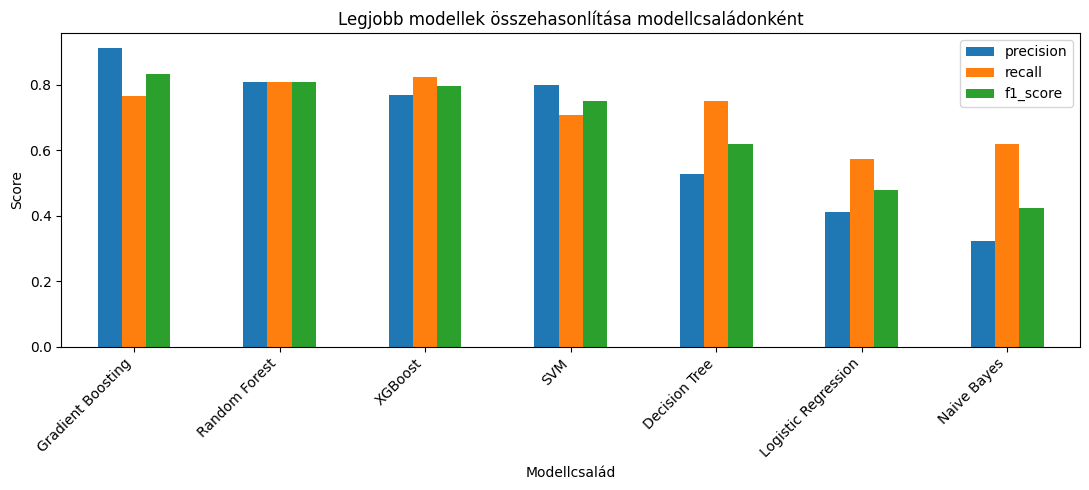

In [21]:
plot_df = best_by_family_df.copy()

plot_df["label"] = plot_df["model_family"]

plot_metrics = ["precision", "recall", "f1_score"]

plot_df.set_index("label")[plot_metrics].plot(
    kind="bar",
    figsize=(11, 5)
)

plt.title("Legjobb modellek összehasonlítása modellcsaládonként")
plt.xlabel("Modellcsalád")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

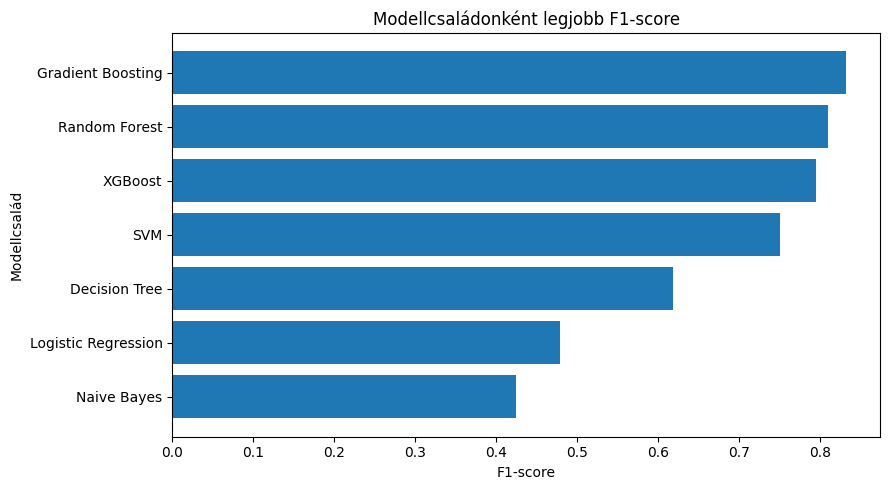

In [22]:
f1_plot_df = best_by_family_df.sort_values("f1_score", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(f1_plot_df["model_family"], f1_plot_df["f1_score"])

plt.title("Modellcsaládonként legjobb F1-score")
plt.xlabel("F1-score")
plt.ylabel("Modellcsalád")
plt.tight_layout()
plt.show()

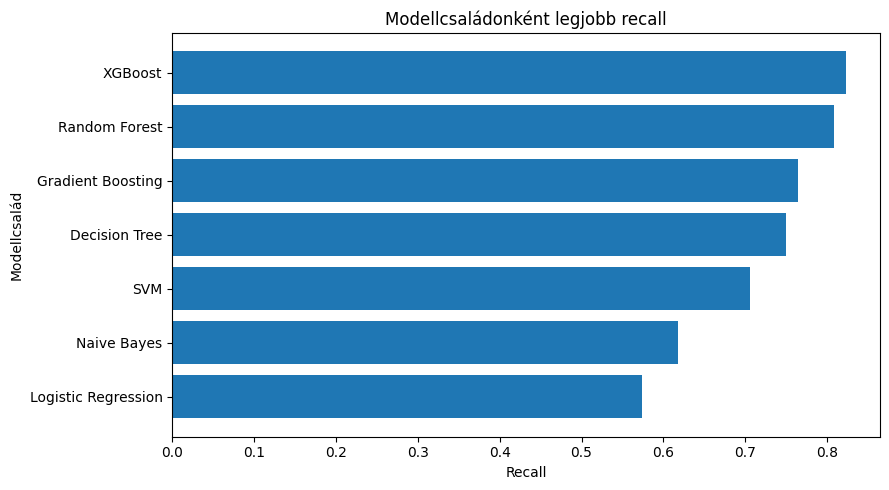

In [23]:
recall_plot_df = best_by_family_df.sort_values("recall", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(recall_plot_df["model_family"], recall_plot_df["recall"])

plt.title("Modellcsaládonként legjobb recall")
plt.xlabel("Recall")
plt.ylabel("Modellcsalád")
plt.tight_layout()
plt.show()

## 8. Accuracy értelmezése

Az accuracy minden modellnél hasznos mutató, de ebben a projektben nem tekinthető önmagában döntő metrikának.

Ennek oka, hogy a célváltozó erősen kiegyensúlyozatlan: a meghibásodás nélküli esetek sokkal gyakoribbak, mint a meghibásodások.

Ezért egy modell magas accuracyt érhet el akkor is, ha a ritka meghibásodási eseteket gyengén ismeri fel.

A végső modellválasztásnál ezért az F1-score, recall és precision fontosabb szerepet kap.

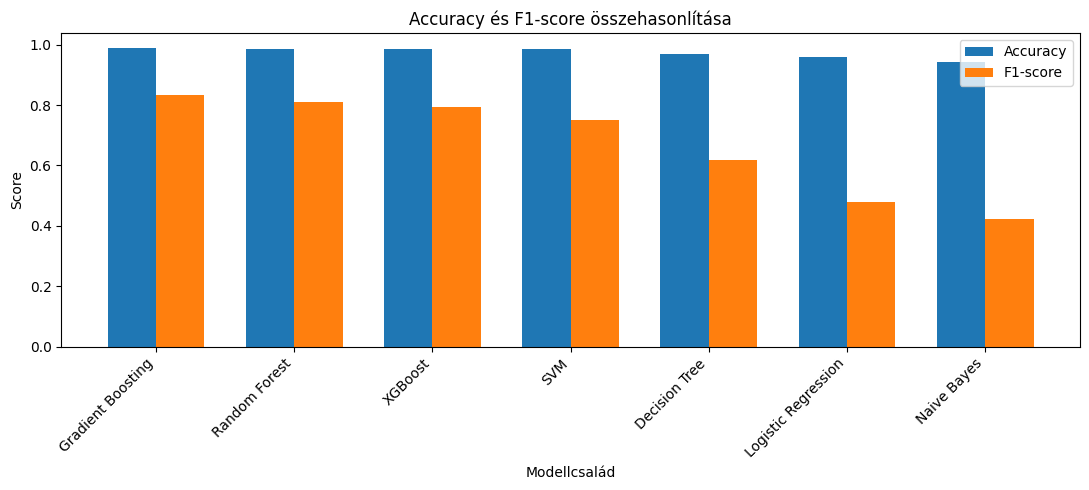

In [24]:
accuracy_f1_df = best_by_family_df.sort_values("f1_score", ascending=False)

x = np.arange(len(accuracy_f1_df))
width = 0.35

plt.figure(figsize=(11, 5))

plt.bar(
    x - width / 2,
    accuracy_f1_df["accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x + width / 2,
    accuracy_f1_df["f1_score"],
    width,
    label="F1-score"
)

plt.title("Accuracy és F1-score összehasonlítása")
plt.xlabel("Modellcsalád")
plt.ylabel("Score")
plt.xticks(x, accuracy_f1_df["model_family"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Legjobb modellek különböző szempontok szerint

A predictive maintenance feladatban nem feltétlenül csak egyetlen metrika alapján érdemes dönteni.

Három szempontot külön is megvizsgálunk:

- legjobb F1-score: legjobb precision-recall egyensúly,
- legjobb recall: legtöbb meghibásodást találja meg,
- legjobb precision: legkevesebb hamis pozitív riasztást adja.

In [25]:
best_f1_model = best_by_family_df.sort_values(
    "f1_score",
    ascending=False
).iloc[0]

best_recall_model = best_by_family_df.sort_values(
    "recall",
    ascending=False
).iloc[0]

best_precision_model = best_by_family_df.sort_values(
    "precision",
    ascending=False
).iloc[0]

best_models_by_metric_df = pd.DataFrame([
    {
        "selection_criterion": "Best F1-score",
        "model_family": best_f1_model["model_family"],
        "model": best_f1_model["model"],
        "precision": best_f1_model["precision"],
        "recall": best_f1_model["recall"],
        "f1_score": best_f1_model["f1_score"],
        "roc_auc": best_f1_model["roc_auc"]
    },
    {
        "selection_criterion": "Best recall",
        "model_family": best_recall_model["model_family"],
        "model": best_recall_model["model"],
        "precision": best_recall_model["precision"],
        "recall": best_recall_model["recall"],
        "f1_score": best_recall_model["f1_score"],
        "roc_auc": best_recall_model["roc_auc"]
    },
    {
        "selection_criterion": "Best precision",
        "model_family": best_precision_model["model_family"],
        "model": best_precision_model["model"],
        "precision": best_precision_model["precision"],
        "recall": best_precision_model["recall"],
        "f1_score": best_precision_model["f1_score"],
        "roc_auc": best_precision_model["roc_auc"]
    }
])

best_models_by_metric_df.round(4)

,selection_criterion,model_family,model,precision,recall,f1_score,roc_auc
0,Best F1-score,Gradient Boosting,GradientBoosting,0.9123,0.7647,0.8320,0.9761
1,Best recall,XGBoost,XGBoost_tuned,0.7671,0.8235,0.7943,0.9768
2,Best precision,Gradient Boosting,GradientBoosting,0.9123,0.7647,0.8320,0.9761


## 10. Modellválasztási logika

A végső modell kiválasztása attól is függ, hogy az üzleti vagy műszaki cél melyik hibát tartja súlyosabbnak.

Ha a cél a lehető legtöbb meghibásodás felismerése, akkor a recall a legfontosabb. Ebben az esetben több hamis riasztást is elfogadhatunk.

Ha a cél a hamis riasztások minimalizálása, akkor a precision fontosabb.

Ha kiegyensúlyozott megoldást keresünk, akkor az F1-score alapján érdemes dönteni.

Ebben a projektben az F1-score-t tekintjük elsődleges metrikának, mert egyszerre veszi figyelembe a precision és recall értékét.

In [26]:
recommended_model = best_f1_model

recommended_model_summary = pd.DataFrame([{
    "recommended_model_family": recommended_model["model_family"],
    "recommended_model": recommended_model["model"],
    "version": recommended_model["version"],
    "threshold_type": recommended_model["threshold_type"],
    "threshold": recommended_model["threshold"],
    "accuracy": recommended_model["accuracy"],
    "precision": recommended_model["precision"],
    "recall": recommended_model["recall"],
    "f1_score": recommended_model["f1_score"],
    "roc_auc": recommended_model["roc_auc"],
    "average_precision": recommended_model["average_precision"],
    "source_file": recommended_model["source_file"]
}])

recommended_model_summary.round(4)

,recommended_model_family,recommended_model,version,threshold_type,threshold,accuracy,precision,recall,f1_score,roc_auc,average_precision,source_file
0,Gradient Boosting,GradientBoosting,baseline,NaN,NaN,0.9895,0.9123,0.7647,0.832,0.9761,0.8665,boosting_results_tuned.csv


## 11. Eredmények mentése

Az egységesített eredménytáblákat CSV fájlba mentjük, hogy a dokumentációban, prezentációban vagy további elemzésekben is felhasználhatók legyenek.

In [27]:
OUTPUT_ALL_RESULTS = Path("all_model_results_standardized.csv")
OUTPUT_BEST_BY_FAMILY = Path("best_model_by_family.csv")
OUTPUT_BEST_BY_METRIC = Path("best_models_by_metric.csv")
OUTPUT_RECOMMENDED = Path("recommended_model_summary.csv")

all_model_results_df.to_csv(OUTPUT_ALL_RESULTS, index=False)
best_by_family_df.to_csv(OUTPUT_BEST_BY_FAMILY, index=False)
best_models_by_metric_df.to_csv(OUTPUT_BEST_BY_METRIC, index=False)
recommended_model_summary.to_csv(OUTPUT_RECOMMENDED, index=False)

print("Mentett fájlok:")
print(OUTPUT_ALL_RESULTS.resolve())
print(OUTPUT_BEST_BY_FAMILY.resolve())
print(OUTPUT_BEST_BY_METRIC.resolve())
print(OUTPUT_RECOMMENDED.resolve())

Mentett fájlok:
C:\Users\aszen\Desktop\ÓBUDAI MSC\02_2025-2026-2\05_Gépi tanulás\MLBeadando\Codes\ModelComparison\all_model_results_standardized.csv
C:\Users\aszen\Desktop\ÓBUDAI MSC\02_2025-2026-2\05_Gépi tanulás\MLBeadando\Codes\ModelComparison\best_model_by_family.csv
C:\Users\aszen\Desktop\ÓBUDAI MSC\02_2025-2026-2\05_Gépi tanulás\MLBeadando\Codes\ModelComparison\best_models_by_metric.csv
C:\Users\aszen\Desktop\ÓBUDAI MSC\02_2025-2026-2\05_Gépi tanulás\MLBeadando\Codes\ModelComparison\recommended_model_summary.csv


## 12. Végső összefoglaló

A modellösszehasonlítás során a különböző notebookokból származó eredményeket egységes formátumra alakítottuk, majd modellcsaládonként kiválasztottuk a legjobb eredményt F1-score alapján.

Az F1-score azért volt elsődleges kiválasztási metrika, mert az adathalmaz erősen kiegyensúlyozatlan, így az accuracy önmagában nem mutatja megfelelően, hogy a modell mennyire képes felismerni a ritka meghibásodási eseteket.

A végső összehasonlítás alapján a legjobb modellcsalád az F1-score szerint: **[IDE ÍRJUK MAJD A LEGJOBB MODELLT]**.

A legjobb recall értéket adó modell: **[IDE ÍRJUK MAJD A LEGJOBB RECALL MODELLT]**.

A legjobb precision értéket adó modell: **[IDE ÍRJUK MAJD A LEGJOBB PRECISION MODELLT]**.

Összességében a fa alapú ensemble modellek várhatóan erős teljesítményt adnak ezen a tabuláris predictive maintenance adathalmazon, mert jól tudják kezelni a nemlineáris kapcsolatokat és a változók közötti interakciókat.

In [28]:
print("Végső modellösszehasonlítás összefoglaló")
print("=" * 80)

print("\nLegjobb F1-score alapján:")
print(f"Modellcsalád: {best_f1_model['model_family']}")
print(f"Modell: {best_f1_model['model']}")
print(f"F1-score: {best_f1_model['f1_score']:.4f}")
print(f"Precision: {best_f1_model['precision']:.4f}")
print(f"Recall: {best_f1_model['recall']:.4f}")
print(f"ROC-AUC: {best_f1_model['roc_auc']:.4f}")

print("\nLegjobb recall alapján:")
print(f"Modellcsalád: {best_recall_model['model_family']}")
print(f"Modell: {best_recall_model['model']}")
print(f"Recall: {best_recall_model['recall']:.4f}")
print(f"Precision: {best_recall_model['precision']:.4f}")
print(f"F1-score: {best_recall_model['f1_score']:.4f}")

print("\nLegjobb precision alapján:")
print(f"Modellcsalád: {best_precision_model['model_family']}")
print(f"Modell: {best_precision_model['model']}")
print(f"Precision: {best_precision_model['precision']:.4f}")
print(f"Recall: {best_precision_model['recall']:.4f}")
print(f"F1-score: {best_precision_model['f1_score']:.4f}")

Végső modellösszehasonlítás összefoglaló

Legjobb F1-score alapján:
Modellcsalád: Gradient Boosting
Modell: GradientBoosting
F1-score: 0.8320
Precision: 0.9123
Recall: 0.7647
ROC-AUC: 0.9761

Legjobb recall alapján:
Modellcsalád: XGBoost
Modell: XGBoost_tuned
Recall: 0.8235
Precision: 0.7671
F1-score: 0.7943

Legjobb precision alapján:
Modellcsalád: Gradient Boosting
Modell: GradientBoosting
Precision: 0.9123
Recall: 0.7647
F1-score: 0.8320


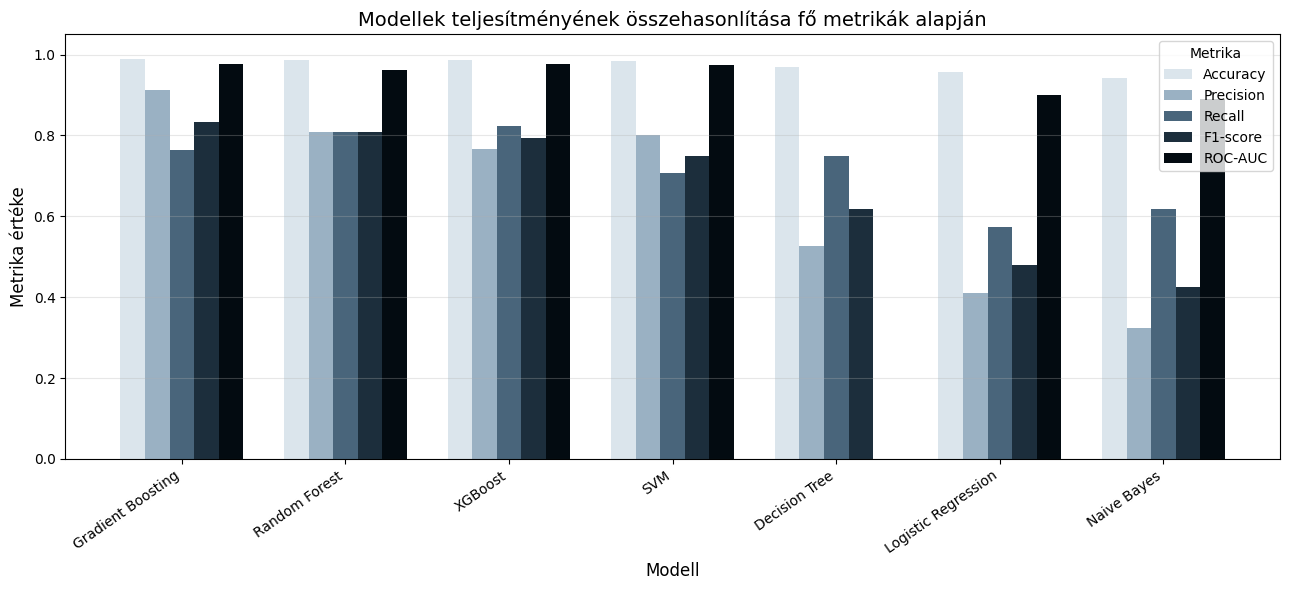

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Ha a model_comparison.ipynb-ben már létezik a best_by_family_df,
# akkor ebből készítjük az ábrát.
plot_df = best_by_family_df.copy()

# Modellnevek rendezése F1-score alapján, hogy a legjobb modellek elöl legyenek
plot_df = plot_df.sort_values("f1_score", ascending=False)

# Ábrázolandó metrikák
metrics = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

# Szebb megjelenítéshez átnevezések
metric_labels = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1_score": "F1-score",
    "roc_auc": "ROC-AUC"
}

# X tengely pozíciók
x = np.arange(len(plot_df["model_family"]))
width = 0.15

# A te választott színeid
blue_shades = [
    "#DBE5EC",
    "#9AB1C3",
    "#49657B",
    "#1C2E3C",
    "#030B11"
]

plt.figure(figsize=(13, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 2) * width,
        plot_df[metric],
        width,
        label=metric_labels[metric],
        color=blue_shades[i]
    )

plt.title("Modellek teljesítményének összehasonlítása fő metrikák alapján", fontsize=14)
plt.xlabel("Modell", fontsize=12)
plt.ylabel("Metrika értéke", fontsize=12)

plt.xticks(
    x,
    plot_df["model_family"],
    rotation=35,
    ha="right"
)

plt.ylim(0, 1.05)
plt.legend(title="Metrika")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Ábra mentése Word-be illesztéshez
plt.savefig("model_metrics_comparison_blue.png", dpi=300, bbox_inches="tight")

plt.show()